## Seaborn 고수준 그래프 라이브러리
> matplotlib보다 간결한 코드로 이쁘게 만들어주는 고수준 모듈  
> 단, 커스텀을 제한적임. 그래서 matplotlib + seaborn 형태로 구현함.

In [33]:
#0. 모듈 사용
import matplotlib.pyplot as plt
import seaborn as sns

In [34]:
#1. 데이터 불러오기 [월별 매출,고객수]
import pandas as pd
df = pd.read_csv('./data_set/monthly_sales_customers.csv')
#객단가 컬룸 새로 추가 -- 파생변수
df['avg_price'] = df['sales']/df['customers']
df

,month,sales,customers,avg_price
0,1,120,45,2.666667
1,2,135,50,2.700000
2,3,150,55,2.727273
3,4,165,60,2.750000
4,5,180,65,2.769231
5,6,210,75,2.800000
6,7,230,80,2.875000
7,8,220,78,2.820513
8,9,200,70,2.857143
9,10,190,68,2.794118


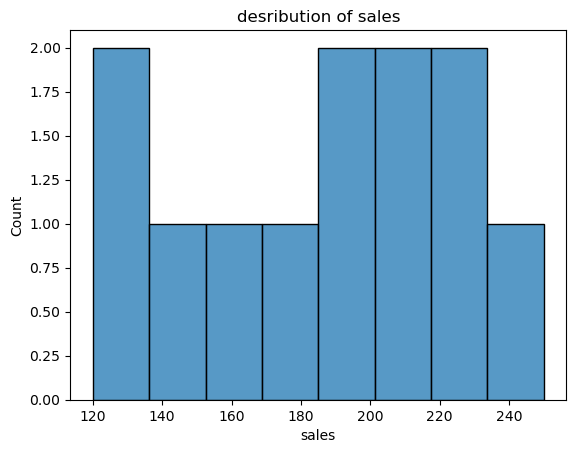

In [35]:
#2. 매출액의 분포 확인 - 단변량 그래프
sns.histplot(df['sales'], bins=8) # x축의 영역구분개수를 지정할 수 있음. 기본 5(최대-최소..균등분할)
plt.title('desribution of sales') 
plt.show()
#matplotlib과 다르게 경계선이 그려짐.

Text(0.5, 1.0, 'destrubution of sales')

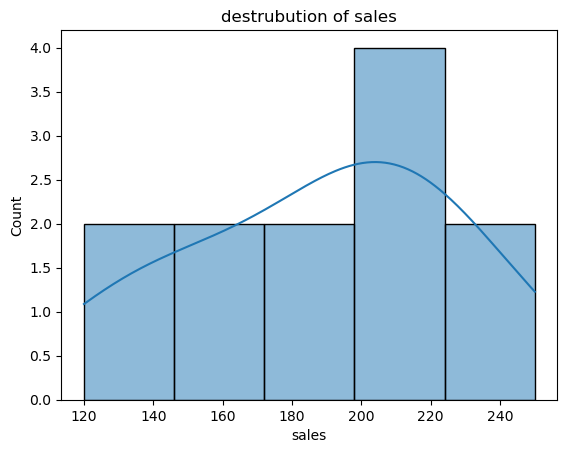

In [36]:
#2-1. 그래프를 그리는 다른 방법
fig, ax = plt.subplots()

sns.histplot(data=df, x='sales', ax=ax, kde=True)
ax.set_title('destrubution of sales')

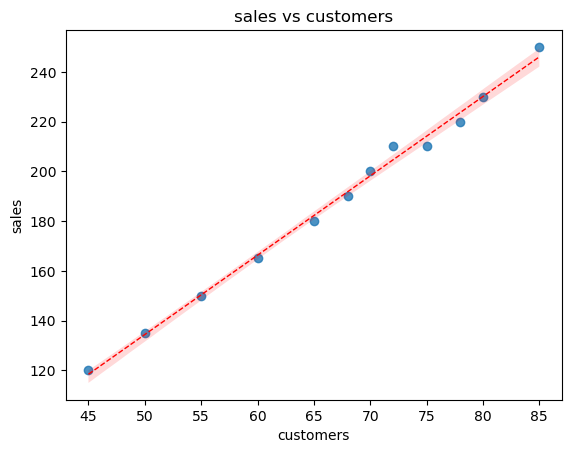

In [37]:
#3. 이변량 그래프 - 산점도
# 고객수에 따른 매출 관계 그래프
#sns.scatterplot(data=df, x='customers', y='sales')

#머신러닝의 회귀선(예측선)을 그려주는 기능
sns.regplot(
    data=df, 
    x='customers', 
    y='sales', 
    # 점,선 스타일...
    scatter_kws={'alpha':0.8},
    line_kws={'color':'red','linestyle':'--', 'linewidth':1}
) 

plt.title('sales vs customers')
plt.show()

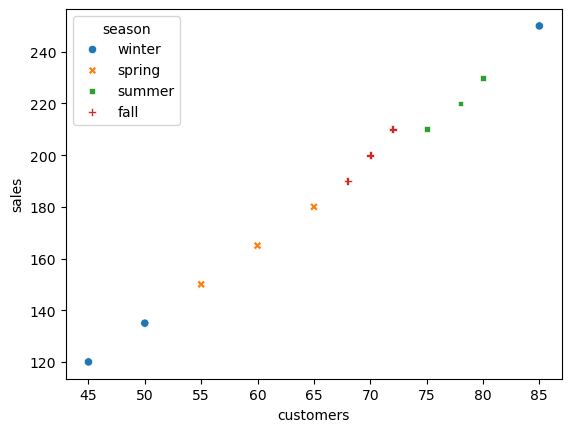

In [38]:
#4. 다변량 그래프 (색상이나 크기를 통해 변수를 확인하는 방법)
# month 대신 시즌을 구분하는 범주형 데이터 추가 [1~12월까지의 대한 계절 정보 가진 컬룸]
df['season'] = ['winter','winter','spring','spring','spring','summer','summer','summer','fall','fall','fall','winter']

# 고객수별 판매, + 시즌
sns.scatterplot(
    data=df,
    x='customers',
    y='sales',
    hue='season', #시즌별로 색상을 다르게...
    #마커모양도 시즌 구별하는 용도로..
    style='season'
)
plt.show()

<Axes: xlabel='customers', ylabel='sales'>

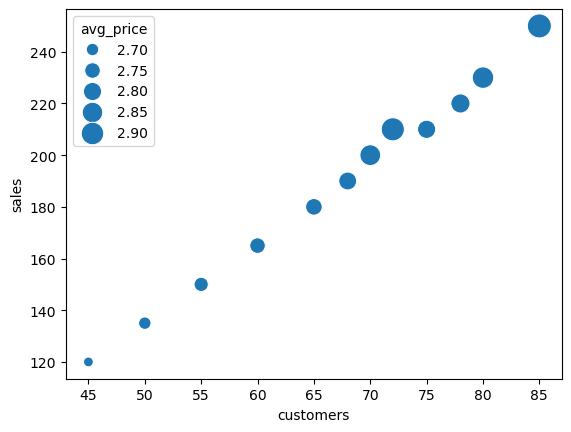

In [39]:
# 크기로 객단가를 표현해보기..
sns.scatterplot(
    data=df,
    x='customers',
    y='sales',
    size='avg_price',
    sizes=(50,300) #50~300 범위로 크기 표시
)

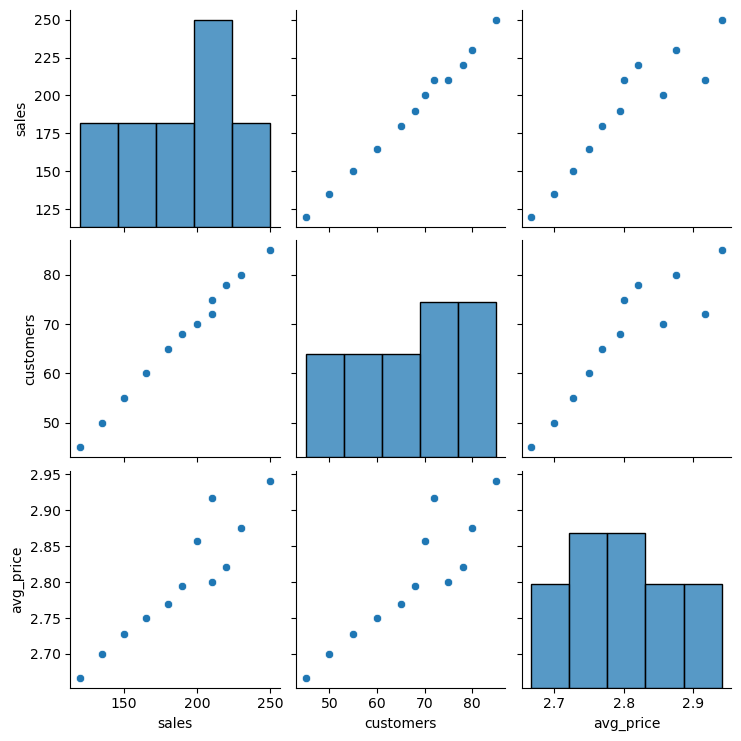

In [40]:
# 5. 변수들의 관계를 한눈에 크로스테이블로 볼수 있는 그래프기능 [쌍 그래프]
sns.pairplot(
    df[['sales','customers','avg_price']]
)
plt.show()

In [41]:
# 데이터셋의 개수가 너무 작아서 그래프의 효용성이 잘 안보임.
# 좀 많은 데이터를 다루기..
# seaborn 모듈에서 anscombe, tips 에 대한 데이터셋을 연습용으로 제공해줌.
tips = sns.load_dataset('tips')
tips

,total_bill,tip,sex,smoker,day,time,size
0,16.99,1.01,Female,No,Sun,Dinner,2
1,10.34,1.66,Male,No,Sun,Dinner,3
2,21.01,3.50,Male,No,Sun,Dinner,3
3,23.68,3.31,Male,No,Sun,Dinner,2
4,24.59,3.61,Female,No,Sun,Dinner,4
...,...,...,...,...,...,...,...
239,29.03,5.92,Male,No,Sat,Dinner,3
240,27.18,2.00,Female,Yes,Sat,Dinner,2
241,22.67,2.00,Male,Yes,Sat,Dinner,2
242,17.82,1.75,Male,No,Sat,Dinner,2


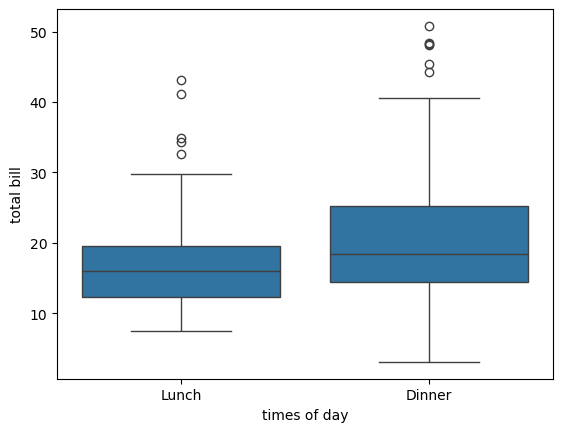

In [42]:
# 점심, 저녁에 따라 지불하는 금액차이가 있는지..분포가 어떤지 비교.
# 박스플롯
fig, ax = plt.subplots()
sns.boxplot(data=tips, x='time', y='total_bill', ax = ax)
ax.set_xlabel('times of day')
ax.set_ylabel('total bill')
plt.show()
# Dinner가 Lunch보다 중앙값이 더 높으니.. 더 지출이 크다!!!
# 박스가 얇다는 것은 변동이 더 적다!!
# Dinner의 수염이 더 길어.... 이상치가 더 큰 차이로 있다.

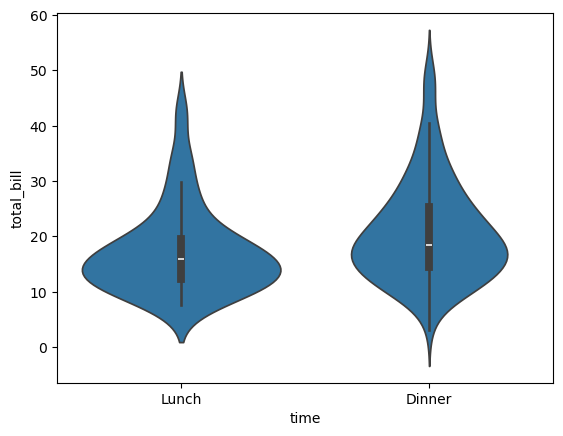

In [43]:
# 박스안의 분포가 잘 안보임..
# 이를 개선한 그래프..바이올린 그래프..
fig, ax=plt.subplots()
sns.violinplot(data= tips, x='time', y='total_bill', ax=ax)
plt.show()

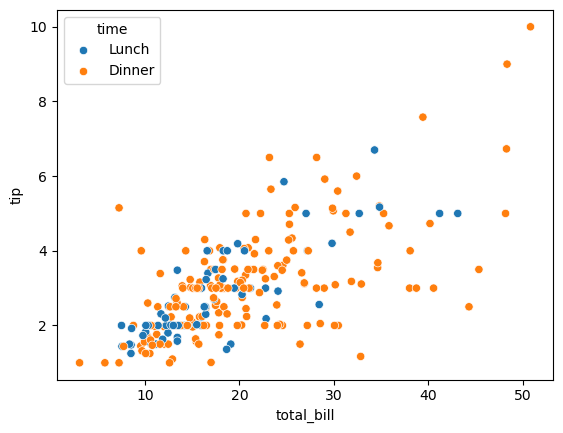

In [44]:
# 다변량 그래프.. 산점도..
fig, ax=plt.subplots()
sns.scatterplot(
    data=tips,
    x='total_bill',
    y='tip',
    hue='time', #점심과 저녁을 색상으로 구분
    ax = ax
)
plt.show()

In [45]:
# 그래프 여러개 그리기.. 패싯..그리기..
print(tips['day'].unique())

['Sun', 'Sat', 'Thur', 'Fri']
Categories (4, object): ['Thur', 'Fri', 'Sat', 'Sun']


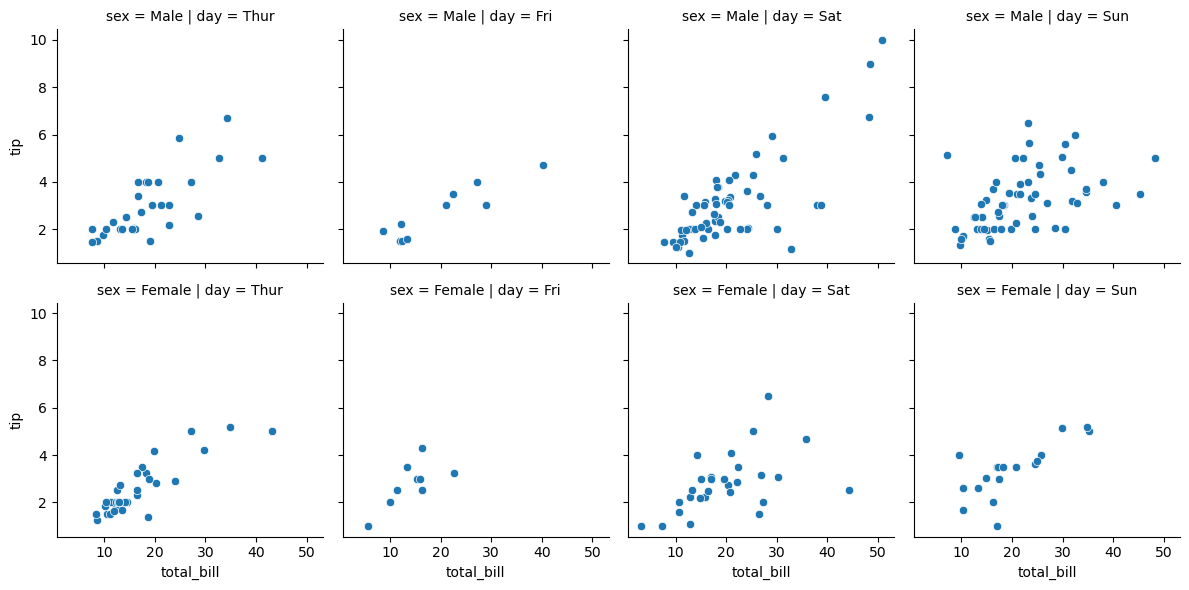

In [46]:
# 요일별 총금액과 tip을 표시..
# 하위 그래프를 알아서 day의 값 종류 개수 만큼
grid = sns.FacetGrid(tips, col='day', row='sex') #성별로 행 개수.. [col, row는 범주형 데이터일때 적합]
# 각 하위그래프에 데이터를 매핑
grid.map(sns.scatterplot, "total_bill", "tip")
plt.show()

In [47]:
# 변수들간의 상관관계를 파악하는 상관계수를 그려주는 heatmap 
# 상관계수 : correlation - 두 변수 사이의 선형 관계의 방향과 강도를 -1~1사이의 숫자로 나타낸 통계적 지표.

#예) 공부시간, 출석률 등에 따른 시험성적의 관계 분석
# 시험성적을 예측하거나 학습관리 도와주는 AI서비스를 제작할때 어떤 요인들이
# 시험성적에 영향을 주는지 직관적으로 생각하지 말고.. 관측된 데이터를 수집하여.
# 시험성적(결과)에 영향을 주는 변수들(요인)을 찾을 때 상관관계를 사용하며 한눈에 보기위해
# 시각화 한것이 heatmap

In [48]:
students= pd.read_csv('./data_set/students.csv')
students

,Study_Hours,Sleep_Hours,Smartphone_Hours,Attendance,Exam_Score
0,5.2,7.3,1.0,86.8,66.5
1,4.3,7.4,2.4,84.4,57.7
2,5.5,7.9,1.3,95.6,77.5
3,6.8,7.8,1.0,100.0,91.9
4,4.1,5.9,2.7,86.5,54.8
...,...,...,...,...,...
95,2.3,6.4,5.0,76.9,40.0
96,4.9,7.7,1.3,81.2,62.7
97,4.9,7.2,2.2,96.3,70.0
98,4.5,7.7,2.5,87.5,58.3


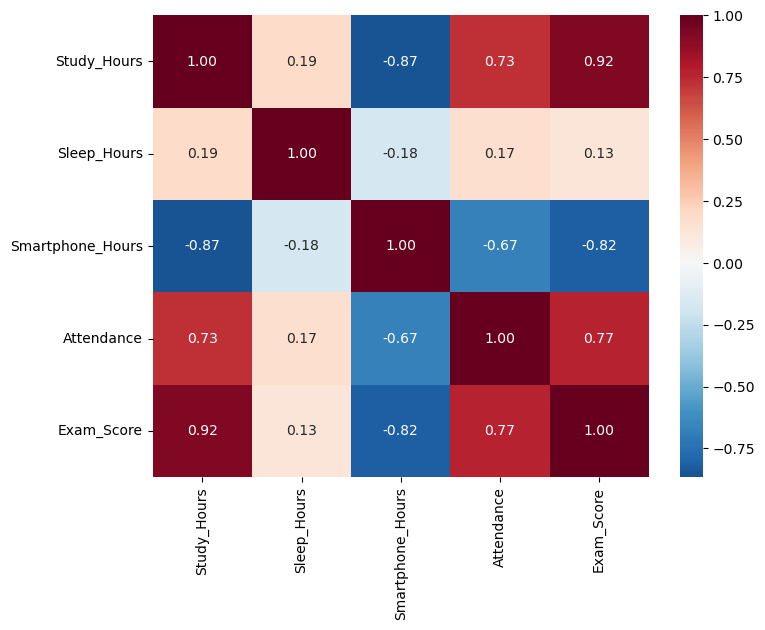

In [49]:
#Heatmap 그리기
plt.figure(figsize=(8,6))
sns.heatmap(
    students.corr(numeric_only=True),  #수치형 변수들의 상관관계를 구해주는 기능
    annot=True,                        #수치값이 박스안에 표시됨
    cmap="RdBu_r",                     #색상맵(빨강=양의 상관, 파랑=음의 상관)
    center=0,
    fmt='.2f',                         #소수점 2자리까지만     
)
plt.show()
# 공부시간 study_Houre와 시험성적의 상관관계는 0.92 로 매우 높음.. 가장 높기에 ...가장 영향이 강한 변수
# 잠자는 시간  sleep_Hours는 시험성적의 상관관계는 0.13 으로 매누 낮음..그러니.성적에 별 영향이 없음.
# 스마트폰 사용시간은 시험성적 과 -0.82 의 음의 상관관계 .. 스마트폰을 많이 쓰면..성적이 내려간다..

# 시험성적은. '공부시간, 출석률, 스마트폰시간'에 비교적 강한 상관성을 보여줌.
# 그리너 시험예측이나 학습관리같은 서비스를 개발한때.. 독립변수로 채택하고..종속변수로 시험감독을 사용!

#즉, 머신러닝을 학습시킬때.. 어떤 변수를 독립변수로 할지..어떤 변수를 종속변수로 할지 결정할때 활용.